In [2]:
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [3]:
df = pd.read_csv("../data/processed/clean_news.csv")

df = df.dropna(subset=["clean_text"])

df.head()

,text,label,clean_text
0,Gere faults Trump for blurring meaning of 'ref...,1,gere fault trump blurring meaning refugee terr...
1,German parties start to find common ground in ...,1,german party start find common ground coalitio...
2,Senate Democratic leader says Attorney General...,1,senate democratic leader say attorney general ...
3,"Tennis: Kyrgios fined $10,000 for Shanghai wal...",1,tennis kyrgios fined shanghai walk tennis chin...
4,Trump Threw Mar-A-Lago Fundraiser For Woman A...,0,trump threw maralago fundraiser woman center b...


In [4]:
X = df["clean_text"]
y = df["label"]

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [6]:
tfidf = TfidfVectorizer(max_features=5000)

X_train_tfidf = tfidf.fit_transform(X_train)

X_test_tfidf = tfidf.transform(X_test)

In [7]:
print(X_train_tfidf.shape)
print(X_test_tfidf.shape)

print(len(y_train))
print(len(y_test))

(36601, 5000)
(9151, 5000)
36601
9151


In [8]:
print("Training TF-IDF Shape :", X_train_tfidf.shape)
print("Testing TF-IDF Shape  :", X_test_tfidf.shape)

print("Training Labels :", len(y_train))
print("Testing Labels  :", len(y_test))

Training TF-IDF Shape : (36601, 5000)
Testing TF-IDF Shape  : (9151, 5000)
Training Labels : 36601
Testing Labels  : 9151


In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

lr = LogisticRegression(max_iter=1000, random_state=42)

lr.fit(X_train_tfidf, y_train)

y_pred_lr = lr.predict(X_test_tfidf)

lr_acc = accuracy_score(y_test, y_pred_lr)
lr_precision = precision_score(y_test, y_pred_lr)
lr_recall = recall_score(y_test, y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr)

print("Accuracy :", lr_acc)
print("Precision:", lr_precision)
print("Recall   :", lr_recall)
print("F1 Score :", lr_f1)

Accuracy : 0.9741011911266528
Precision: 0.973816277547458
Recall   : 0.9744541484716157
F1 Score : 0.9741351085888901


In [10]:
from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB()

nb.fit(X_train_tfidf, y_train)

y_pred_nb = nb.predict(X_test_tfidf)

nb_acc = accuracy_score(y_test, y_pred_nb)
nb_precision = precision_score(y_test, y_pred_nb)
nb_recall = recall_score(y_test, y_pred_nb)
nb_f1 = f1_score(y_test, y_pred_nb)

print("Accuracy :", nb_acc)
print("Precision:", nb_precision)
print("Recall   :", nb_recall)
print("F1 Score :", nb_f1)

Accuracy : 0.9141077477871271
Precision: 0.9158263919333626
Recall   : 0.9122270742358078
F1 Score : 0.914023189674032


In [11]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_tfidf, y_train)

y_pred_rf = rf.predict(X_test_tfidf)

rf_acc = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)

print("Accuracy :", rf_acc)
print("Precision:", rf_precision)
print("Recall   :", rf_recall)
print("F1 Score :", rf_f1)

Accuracy : 0.9796743525297782
Precision: 0.993486073674753
Recall   : 0.9657205240174672
F1 Score : 0.979406554472985


In [12]:
from sklearn.svm import LinearSVC

svm = LinearSVC(random_state=42)

svm.fit(X_train_tfidf, y_train)

y_pred_svm = svm.predict(X_test_tfidf)

svm_acc = accuracy_score(y_test, y_pred_svm)
svm_precision = precision_score(y_test, y_pred_svm)
svm_recall = recall_score(y_test, y_pred_svm)
svm_f1 = f1_score(y_test, y_pred_svm)

print("Accuracy :", svm_acc)
print("Precision:", svm_precision)
print("Recall   :", svm_recall)
print("F1 Score :", svm_f1)

Accuracy : 0.9809856846246312
Precision: 0.9801656495204882
Recall   : 0.9818777292576419
F1 Score : 0.981020942408377


# K-Nearest Neighbors (KNN)

In [13]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_tfidf, y_train)

y_pred_knn = knn.predict(X_test_tfidf)

knn_acc = accuracy_score(y_test, y_pred_knn)
knn_precision = precision_score(y_test, y_pred_knn)
knn_recall = recall_score(y_test, y_pred_knn)
knn_f1 = f1_score(y_test, y_pred_knn)

print("Accuracy :", knn_acc)
print("Precision:", knn_precision)
print("Recall   :", knn_recall)
print("F1 Score :", knn_f1)

Accuracy : 0.8746585072669654
Precision: 0.8600797147052653
Recall   : 0.8951965065502183
F1 Score : 0.8772868299989302


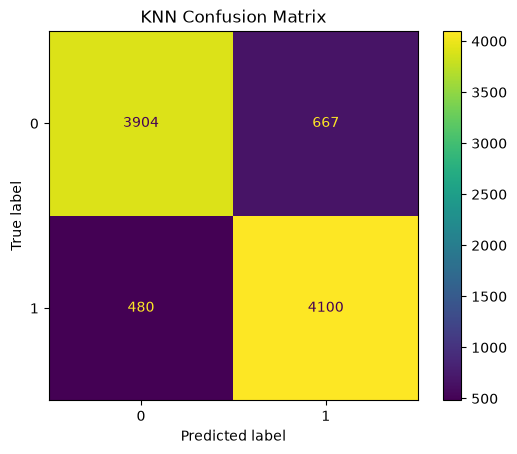

In [14]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_knn)

plt.title("KNN Confusion Matrix")

plt.show()


Neural Network (MLPClassifier)

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier

# Use only 10,000 training samples
X_small, _, y_small, _ = train_test_split(
    X_train_tfidf,
    y_train,
    train_size=10000,
    random_state=42,
    stratify=y_train
)

mlp = MLPClassifier(
    hidden_layer_sizes=(20,),
    max_iter=20,
    random_state=42,
    early_stopping=True
)

mlp.fit(X_small, y_small)

y_pred_mlp = mlp.predict(X_test_tfidf)

mlp_acc = accuracy_score(y_test, y_pred_mlp)

print("Accuracy:", mlp_acc)

Accuracy: 0.9639383673915419


C:\Users\Bijesh Poswal\Downloads\ai\envs\fake_news\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


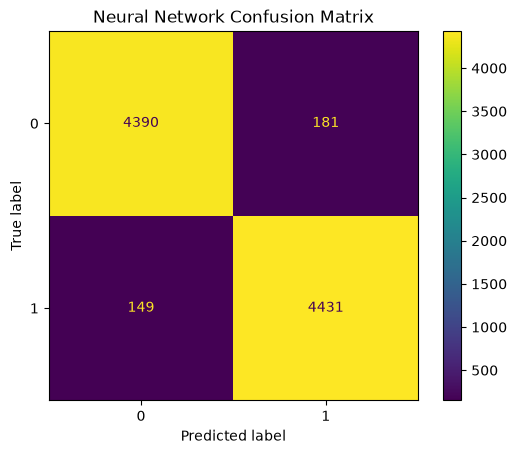

In [17]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_mlp
)

plt.title("Neural Network Confusion Matrix")

plt.show()